# IMPORTING LIBRARIES

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# LOADING THE DATASET

In [ ]:
data = load_breast_cancer()
X = data.data
y_true = data.target


# SCALE THE DATA

In [ ]:
# VERY IMPORTANT for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# COUNTPLOT & HISTOGRAM

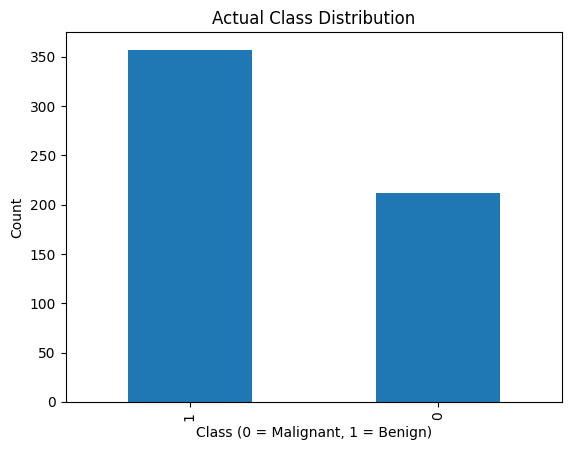

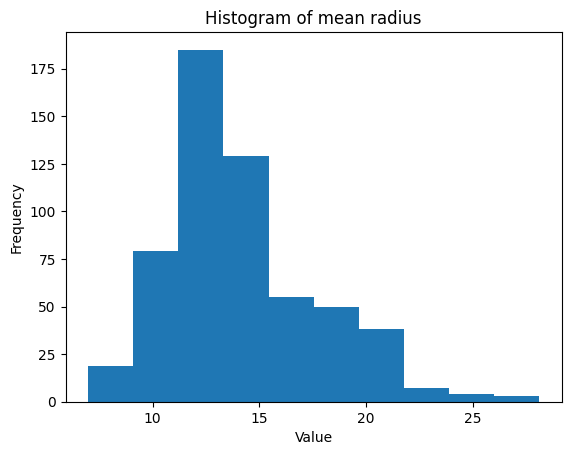

In [ ]:
# ------------------ PLOT 1: Countplot ------------------
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y_true

plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Actual Class Distribution")
plt.xlabel("Class (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

# ------------------ PLOT 2: Histogram ------------------
plt.figure()
plt.hist(df[data.feature_names[0]])
plt.title(f"Histogram of {data.feature_names[0]}")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# PERFORMING K-MEANS CLUSTERING

In [ ]:
# ------------------ KMeans Clustering ------------------
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ------------------ Convert Cluster Labels ------------------
# Clustering labels are arbitrary (0/1), so align with true labels
# Flip labels if needed
if accuracy_score(y_true, clusters) < accuracy_score(y_true, 1 - clusters):
    clusters = 1 - clusters

# ------------------ Evaluation ------------------
print("Accuracy:", accuracy_score(y_true, clusters))

cm = confusion_matrix(y_true, clusters)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9121265377855887
Confusion Matrix:
 [[175  37]
 [ 13 344]]


# CLUSTER VISUALIZATION

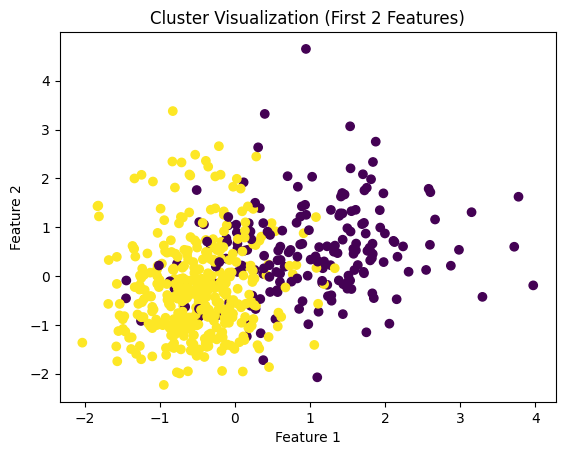

In [ ]:
# ------------------ PLOT : Cluster Visualization ------------------
# Use 2 features for visualization
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("Cluster Visualization (First 2 Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()